# Day 2 Walkthrough: Making A Table Fit To Model

Yesterday we fitted models to data that somebody had already cleaned. That is
not how data arrives. This hour works through a table that is broken in four
ordinary ways, and the point is that every repair is a decision you are making
on the reader's behalf, whether or not you notice making it.

The dataset is a catalogue of 10000 consumer electronics products. It has gaps
in four columns, it stores three separate measurements inside one text field,
it stores two categories inside another, and it stores dates as text. None of
that is exotic. All four appear in almost every table you will ever be handed.

| Section | Minutes |
| --- | --- |
| Orientation | 3 |
| 1. What Is Wrong With This Table | 10 |
| 2. Missing Values And Why The Pattern Matters More Than The Count | 12 |
| 3. Filling A Gap And Measuring Whether It Helped | 12 |
| 4. Values Trapped Inside Strings | 9 |
| 5. Categories And Dates | 9 |
| 6. Did Any Of It Help | 4 |
| 7. What To Take Away | 1 |

## Orientation (3 Minutes)

The habits from yesterday still apply. Restart the kernel and run every cell in
order if anything stops making sense, read the minimum and the maximum of every
numeric column before you trust it, and print a baseline next to every number
you intend to interpret.

One habit is new today and it is the important one. Data preparation is not a
chore you complete before the real work starts. Every choice made here changes
the answer the model gives, and unlike a modelling mistake it leaves no trace
in the output. A model that scores badly announces itself. A column that was
quietly filled with the wrong value does not.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Every notebook resolves its data through a path relative to itself, so the
# materials work the same way on JupyterHub and on a laptop.
DATA_DIR = Path.cwd().parent / "data"

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 110)

print("Reading data from:", DATA_DIR)

Reading data from: /Users/dimitar.peshevski/workspace/ml-workshop/Day 2 - Data Preparation and Processing/data


## 1. What Is Wrong With This Table (10 Minutes)

Read it, then look at it before doing anything else.

In [2]:
products = pd.read_csv(DATA_DIR / "products.csv")

print("Rows:", len(products))
print("Columns:", len(products.columns))
products.head()

Rows: 10000
Columns: 10


,Product ID,Product Name,Price,Stock Quantity,Warranty Period,Product Dimensions,Manufacturing Date,Expiration Date,Color/Size Variations,Product Ratings
0,93TGNAY7,Laptop,NaN,3.0,2.0,16x15x15 cm,2023-01-01,2026-01-01,Green/Large,NaN
1,TYYZ5AV7,Smartphone,214.37,92.0,2.0,15x19x19 cm,2023-03-15,2025-01-01,Red/Small,2.0
2,5C94FGTQ,Headphones,475.29,19.0,2.0,9x6x6 cm,2023-03-15,2026-01-01,Red/Small,NaN
3,XBHKYPQB,Monitor,NaN,40.0,1.0,7x13x5 cm,2023-01-01,2026-01-01,Green/Large,NaN
4,728GCZFU,Laptop,229.81,32.0,2.0,20x20x19 cm,2023-07-30,2026-01-01,Blue/Medium,4.0


In [3]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product ID             10000 non-null  str    
 1   Product Name           10000 non-null  str    
 2   Price                  8500 non-null   float64
 3   Stock Quantity         8605 non-null   float64
 4   Warranty Period        8800 non-null   float64
 5   Product Dimensions     10000 non-null  str    
 6   Manufacturing Date     10000 non-null  str    
 7   Expiration Date        10000 non-null  str    
 8   Color/Size Variations  10000 non-null  str    
 9   Product Ratings        7638 non-null   float64
dtypes: float64(4), str(6)
memory usage: 781.4 KB


Read the `Dtype` column rather than the counts for a moment. Four columns are
numeric and six hold text, which pandas reports as `str`. Two of those six are
text only because nobody has parsed them yet.

`Product Dimensions` holds a string such as `16x15x15 cm`, which is three
numbers and a unit crammed into one field. `Manufacturing Date` and
`Expiration Date` hold dates that pandas is treating as ordinary strings, so
subtracting one from the other is currently impossible. `Color/Size Variations`
holds two independent categories joined by a slash.

None of these is usable by a model in its present form, and none of them is
damaged. The information is there, it is simply in the wrong shape.

In [4]:
products.describe()

,Price,Stock Quantity,Warranty Period,Product Ratings
count,8500.000000,8605.000000,8800.000000,7638.000000
mean,254.767901,50.595119,2.015000,3.025007
std,143.028881,28.912863,0.819832,1.425383
min,10.220000,1.000000,1.000000,1.000000
25%,129.855000,25.000000,1.000000,2.000000
50%,252.715000,50.000000,2.000000,3.000000
75%,380.837500,76.000000,3.000000,4.000000
max,499.970000,100.000000,3.000000,5.000000


The `count` row is the one to read first. It reports 8500 prices, 8605 stock
quantities, 8800 warranty periods, and 7638 ratings, against 10000 rows. Four
columns have gaps and the remaining six do not.

The `min` and `max` rows are unremarkable, which is worth saying out loud.
Price runs from 10.22 to 499.97, stock from 1 to 100, and ratings from 1 to 5.
There are no negative prices and no impossible ratings, so this particular
table has no out-of-range problem. The laboratory exercise this afternoon has
one.

## 2. Missing Values And Why The Pattern Matters More Than The Count (12 Minutes)

Counting gaps is the easy half. The half that decides what you should do about
them is finding out whether the gaps fall at random or fall somewhere specific.

In [5]:
gaps = pd.DataFrame(
    {
        "missing": products.isna().sum(),
        "percent": (products.isna().mean() * 100).round(2),
    }
)
gaps[gaps["missing"] > 0]

,missing,percent
Price,1500,15.00
Stock Quantity,1395,13.95
Warranty Period,1200,12.00
Product Ratings,2362,23.62


Between 12 and 24 percent of four columns is absent. Taken one column at a time
that sounds survivable. The number that actually governs the decision is how
many rows survive if you require every column to be present.

In [6]:
complete = products.notna().all(axis=1).sum()

print(f"Rows with no gap at all:      {complete}")
print(f"Rows with at least one gap:   {len(products) - complete}")
print(f"Share of the table lost by dropping incomplete rows: "
      f"{(1 - complete / len(products)) * 100:.1f}%")

products.isna().sum(axis=1).value_counts().sort_index()

Rows with no gap at all:      5503
Rows with at least one gap:   4497
Share of the table lost by dropping incomplete rows: 45.0%


0    5503
1    2980
2    1105
3     381
4      31
Name: count, dtype: int64

This is the result that changes the plan. Four columns each missing a modest
fraction combine into 4497 affected rows, so `dropna` would discard 45 percent
of the table. Gaps spread thinly across many columns are far more expensive
than the individual percentages suggest, because a row needs only one of them
to be lost.

The last table above shows the same fact from the other side. 5503 rows are
complete, 2980 are missing exactly one value, and 31 rows are missing four.

### Where Do The Gaps Fall

Whether imputation is honest depends on why the value is absent. The
distinction that matters in practice is whether the absence is related to
something else in the table.

If prices were missing mainly for expensive products, then filling them with
the median would systematically understate those products, and every later
analysis would inherit that bias. So check.

In [7]:
by_product = pd.DataFrame(
    {
        "price missing": products.groupby("Product Name")["Price"].apply(lambda s: s.isna().mean()),
        "stock missing": products.groupby("Product Name")["Stock Quantity"].apply(lambda s: s.isna().mean()),
        "rating missing": products.groupby("Product Name")["Product Ratings"].apply(lambda s: s.isna().mean()),
    }
)
(by_product * 100).round(1)

,price missing,stock missing,rating missing
Product Name,,,
Headphones,14.3,13.2,23.7
Laptop,15.0,14.6,22.2
Monitor,15.1,14.1,24.5
Smartphone,15.6,14.0,24.1


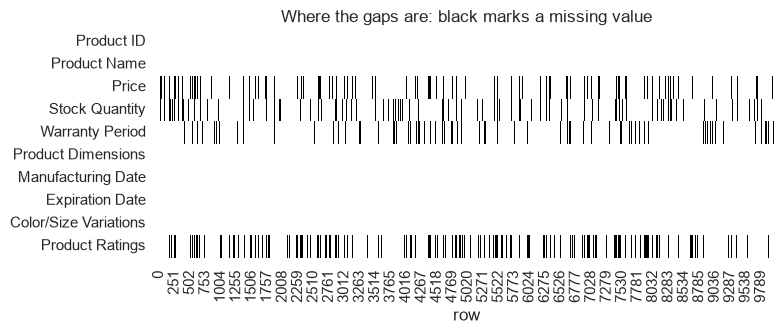

In [8]:
plt.figure(figsize=(8, 3.5))
sns.heatmap(products.isna().T, cbar=False, cmap="Greys")
plt.xlabel("row")
plt.title("Where the gaps are: black marks a missing value")
plt.tight_layout()
plt.show()

The rate is flat. Every product type loses close to 15 percent of its prices
and close to 24 percent of its ratings, and the picture above shows no band, no
block, and no drift from left to right.

That is the easy case, and it is worth naming it. When the probability that a
value is absent has nothing to do with the value itself or with anything else
recorded, the data is called missing completely at random, and a sensible fill
will not bias the result. When it is not the easy case, and usually it is not,
the fill is a claim about values nobody observed, and you are obliged to say so
in the write-up.

There is a third possibility neither check can rule out. Prices might be
missing precisely for the most expensive products, which is a relationship
between the absence and the missing value itself. No amount of staring at the
table can detect that, because the evidence you would need is exactly what is
absent. Only knowledge of how the data was collected settles it.

## 3. Filling A Gap And Measuring Whether It Helped (12 Minutes)

There are three common responses to a gap, and the third is the one people
skip.

The first is to drop the row, which is honest, costs 45 percent of this table,
and is defensible when the gaps are few. The second is to fill with a single
summary value such as the median. The third is to predict the missing value
from the other columns in the same row, which sounds obviously better and often
is not.

### The Single Summary Value

For a numeric column the median is the usual choice, for the reason yesterday
demonstrated, which is that it survives outliers the mean does not. For a
categorical column the mode is the usual choice.

`Warranty Period` shows why the two are not interchangeable.

In [9]:
warranty = products["Warranty Period"]

print("value counts:")
print(warranty.value_counts(dropna=False).sort_index().to_string())
print()
print(f"median: {warranty.median()}")
print(f"mode:   {warranty.mode()[0]}")

value counts:
Warranty Period
1.0    2892
2.0    2884
3.0    3024
NaN    1200

median: 2.0
mode:   3.0


The column is stored as a number but it behaves like a category, since it takes
only the values one, two, and three. The median is 2.0 and the mode is 3.0, and
those two answers fill 1200 rows differently.

Neither is wrong. The median keeps the middle of the distribution and the mode
keeps its most common value, and which one you want depends on what the column
means. What you cannot do is call `fillna` without noticing that a choice was
made.

In [10]:
filled = products.copy()
filled["Warranty Period"] = filled["Warranty Period"].fillna(warranty.median())

print("missing before:", products["Warranty Period"].isna().sum())
print("missing after: ", filled["Warranty Period"].isna().sum())

missing before: 1200
missing after:  0


### Predicting The Gap From Its Neighbours

`KNNImputer` finds the rows most similar to the incomplete one, using whichever
columns are present, and averages their values for the column that is absent.
When the columns genuinely inform each other this is much better than a single
median for the whole table.

The word to notice in that sentence is "when". Let us measure it rather than
assume it, using the same trick that makes a held-out test set work. We hide
1000 prices we already know, impute them both ways, and compare each answer
against the value we hid.

In [11]:
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error

numeric_columns = ["Price", "Stock Quantity", "Product Ratings"]

rng = np.random.default_rng(RANDOM_STATE)
hidden = rng.choice(products.index[products["Price"].notna()], size=1000, replace=False)
truth = products.loc[hidden, "Price"].to_numpy()

masked = products[numeric_columns].copy()
masked.loc[hidden, "Price"] = np.nan

median_guess = np.full(len(hidden), masked["Price"].median())
print(f"filling with the median: MAE {mean_absolute_error(truth, median_guess):.2f}")

filling with the median: MAE 119.76


In [12]:
imputed = KNNImputer(n_neighbors=5).fit_transform(masked)

knn_guess = imputed[products.index.get_indexer(hidden), 0]

print(f"filling with 5 neighbours: MAE {mean_absolute_error(truth, knn_guess):.2f}")

filling with 5 neighbours: MAE 128.25


The neighbour-based method is worse, by about eight and a half currency units
on a typical product. That is not a bug and it is not a tuning problem.

`KNNImputer` decides which rows are similar using stock quantity and rating,
because those are the only other numeric columns available. Neither of them has
any relationship with price in this table, so the five nearest neighbours are
effectively five products picked at random. Averaging five random prices is a
noisier estimate of the middle of the distribution than the median of all 8500
of them, so it loses, and it will keep losing however you set `n_neighbors`.

The lesson generalises past this file. A more sophisticated imputer only beats
the median when the other columns actually carry information about the missing
one. Measure it on values you hid, the way we just did, rather than choosing
the method that sounds most advanced.

### The Rows `KNNImputer` Cannot Reach

The method has a limit on this table that the score above does not reveal.
`KNNImputer` measures the distance between two rows using the columns they both
have, so a row with no observed numeric value at all has no distance to
anything. Count those rows, then look at what they were filled with.

In [13]:
all_three_missing = masked.isna().all(axis=1)
print("Rows with all three numeric columns missing:", int(all_three_missing.sum()))

# A row with nothing observed has no neighbours, so compare what those rows
# received against the column means to see what happened to them instead.
unreachable = imputed[np.flatnonzero(all_three_missing.to_numpy())]

print("Distinct rows among them after imputation:", len(np.unique(unreachable, axis=0)))
print("The values they were given: ", unreachable[0].round(4))
print("The observed column means:  ", masked.mean().to_numpy().round(4))

Rows with all three numeric columns missing: 309
Distinct rows among them after imputation: 1
The values they were given:  [255.163   50.5951   3.025 ]
The observed column means:   [255.163   50.5951   3.025 ]


309 rows have no observed numeric value at all. There is nothing to measure a
distance with, so the notion of a nearest neighbour is undefined for them. All
309 came out identical, and the values they received are the column means, so
`KNNImputer` fell back to the answer `SimpleImputer` would have given without
saying so. That is a reasonable default and it is also not the method the name
promises.

Those 309 rows are worth flagging in a report, because whatever fills them is
an invention rather than an estimate.

In [14]:
prepared = products.copy()
prepared["Warranty Period"] = prepared["Warranty Period"].fillna(products["Warranty Period"].median())
for column in numeric_columns:
    prepared[column] = prepared[column].fillna(products[column].median())

print("Remaining missing values:", int(prepared.isna().sum().sum()))

Remaining missing values: 0


We fill with the median because we measured it and it won. Note that the fill
values come from `products`, the untouched table, so each column is filled from
its own observed values and nothing that was already imputed feeds a later
fill.

One warning about doing this here at all. Imputing across the whole table
before splitting into training and test sets leaks information, in exactly the
way yesterday's scaling example did, because the median is computed partly from
rows the model is later scored on. The correct arrangement is `SimpleImputer`
inside a `Pipeline`, so the fill value is learned from the training rows alone.
We are filling in place today because there is no model at the end of this
notebook, and the moment there is one the imputer belongs in the pipeline.

## 4. Values Trapped Inside Strings (9 Minutes)

`Product Dimensions` reads `16x15x15 cm`. A person can see three numbers there.
A model sees a label, and there are thousands of distinct ones.

In [15]:
print("Distinct values:", products["Product Dimensions"].nunique())
products["Product Dimensions"].head()

Distinct values: 3718


0    16x15x15 cm
1    15x19x19 cm
2       9x6x6 cm
3      7x13x5 cm
4    20x20x19 cm
Name: Product Dimensions, dtype: str

3718 distinct labels, none of which a model can compare against any other. The
three numbers inside them are ordinary measurements that would compare
perfectly well, so the job is to get them out.

Before writing a parser, find out whether every value really has the shape you
think it has. Parsers written against the first five rows are a reliable source
of errors at row 4000.

In [16]:
pattern = r"(\d+)x(\d+)x(\d+) cm"
matches = products["Product Dimensions"].str.fullmatch(pattern)

print("Values matching the expected shape:", int(matches.sum()), "of", len(products))

Values matching the expected shape: 10000 of 10000


Every one of the 10000 values matches, so a single extraction handles the whole
column. Had even one row failed, the honest response would be to look at the
failures before deciding what to do with them, rather than wrapping the parser
in a `try` and letting the exceptions vanish.

In [17]:
dimensions = products["Product Dimensions"].str.extract(pattern).astype(int)
dimensions.columns = ["width_cm", "height_cm", "depth_cm"]

prepared[["width_cm", "height_cm", "depth_cm"]] = dimensions
prepared["volume_cm3"] = dimensions.prod(axis=1)
prepared = prepared.drop(columns=["Product Dimensions"])

prepared[["width_cm", "height_cm", "depth_cm", "volume_cm3"]].describe().round(1)

,width_cm,height_cm,depth_cm,volume_cm3
count,10000.0,10000.0,10000.0,10000.0
mean,12.5,12.5,12.5,1939.1
std,4.6,4.6,4.6,1329.9
min,5.0,5.0,5.0,125.0
25%,8.0,8.0,8.0,950.0
50%,12.0,12.0,12.0,1584.0
75%,16.0,17.0,16.0,2584.0
max,20.0,20.0,20.0,8000.0


Four usable numbers now exist where there was one label. Volume is a derived
feature rather than a recorded one, and it is the sort of thing worth deriving
because a model cannot discover multiplication on its own. A linear model in
particular can only add its inputs together, so a quantity that depends on the
product of three columns has to be handed to it explicitly.

Whether this particular volume helps is a separate question, and Section 6
answers it.

## 5. Categories And Dates (9 Minutes)

`Color/Size Variations` holds two categories in one field. Splitting it is one
line, and checking what the split reveals is the part worth the time.

In [18]:
prepared[["colour", "size"]] = products["Color/Size Variations"].str.split("/", expand=True)
prepared = prepared.drop(columns=["Color/Size Variations"])

pd.crosstab(prepared["colour"], prepared["size"])

size,Large,Medium,Small
colour,,,
Blue,0,3351,0
Green,3296,0,0
Red,0,0,3353


Look at the shape of that table. Every blue product is medium, every green
product is large, and every red product is small. The two columns are not two
pieces of information, they are one piece of information written twice.

Encoding both would hand a model a set of perfectly redundant columns. For a
linear model that is actively harmful, because the fit has no unique solution
and the coefficients become arbitrary and uninterpretable. For a tree it is
merely wasteful. Either way, one of the two should go, and finding this out
took a single cross tabulation.

In [19]:
size_order = {"Small": 0, "Medium": 1, "Large": 2}
prepared["size"] = prepared["size"].map(size_order)
prepared = prepared.drop(columns=["colour"])

prepared["size"].value_counts().sort_index()

size
0    3353
1    3351
2    3296
Name: count, dtype: int64

Size is ordinal, meaning its categories have a genuine order, so mapping it to
0, 1, and 2 preserves real information and costs one column instead of three.
Doing the same thing to an unordered category would be a mistake, because it
would assert that the third category is somehow twice the second.

`Product Name` is unordered, so it gets one column per category instead.

In [20]:
prepared = pd.get_dummies(prepared, columns=["Product Name"], prefix="is", dtype=int)

print([column for column in prepared.columns if column.startswith("is_")])
prepared.filter(like="is_").head()

['is_Headphones', 'is_Laptop', 'is_Monitor', 'is_Smartphone']


,is_Headphones,is_Laptop,is_Monitor,is_Smartphone
0,0,1,0,0
1,0,0,0,1
2,1,0,0,0
3,0,0,1,0
4,0,1,0,0


Four categories become four indicator columns. Yesterday we passed
`drop_first=True` to remove one of them, because the last category is implied
by the others being zero and a linear model needs that redundancy removed. Here
all four are kept, which is the better default for tree-based models and for
anything where you would rather read the columns than fit a line through them.
The choice depends on the model, so make it deliberately.

### Dates

Dates arrive as text and are useless until parsed. Once parsed, the useful
feature is almost never the date itself but a duration or a cyclic component
derived from it.

In [21]:
manufactured = pd.to_datetime(products["Manufacturing Date"])
expires = pd.to_datetime(products["Expiration Date"])

prepared["shelf_life_days"] = (expires - manufactured).dt.days
prepared["manufactured_month"] = manufactured.dt.month
prepared = prepared.drop(columns=["Manufacturing Date", "Expiration Date"])

print("Distinct manufacturing dates:", manufactured.nunique())
print("Distinct expiration dates:  ", expires.nunique())
print("Distinct shelf lives:       ", prepared["shelf_life_days"].nunique())
prepared["shelf_life_days"].value_counts().sort_index()

Distinct manufacturing dates: 3
Distinct expiration dates:   3
Distinct shelf lives:        9


shelf_life_days
155     1072
292     1111
365     1137
521     1099
658     1072
731     1146
886     1089
1023    1111
1096    1163
Name: count, dtype: int64

Shelf life is the feature worth having, because it is the quantity a buyer
actually cares about and neither date carries it alone.

The counts also expose something about this file. There are three manufacturing
dates and three expiration dates in the whole catalogue, so the derived
duration takes nine values across 10000 products. A feature with nine levels is
closer to a category than to a continuous measurement, and treating it as
continuous implies a smoothness the data cannot support. Notice this now rather
than after a model has quietly relied on it.

In [22]:
prepared = prepared.drop(columns=["Product ID"])
prepared.head()

,Price,Stock Quantity,Warranty Period,Product Ratings,width_cm,height_cm,depth_cm,volume_cm3,size,is_Headphones,is_Laptop,is_Monitor,is_Smartphone,shelf_life_days,manufactured_month
0,252.715,3.0,2.0,3.0,16,15,15,3600,2,0,1,0,0,1096,1
1,214.370,92.0,2.0,2.0,15,19,19,5415,0,0,0,0,1,658,3
2,475.290,19.0,2.0,3.0,9,6,6,324,0,1,0,0,0,1023,3
3,252.715,40.0,1.0,3.0,7,13,5,455,2,0,0,1,0,1096,1
4,229.810,32.0,2.0,4.0,20,20,19,7600,1,0,1,0,0,886,7


`Product ID` is dropped because it is unique to each row. An identifier carries
no information that generalises to a product the model has not seen, and
handing one to a flexible model invites it to memorise the training set.

## 6. Did Any Of It Help (4 Minutes)

We have filled 6457 gaps, parsed three numbers out of a string, derived a
volume, collapsed a redundant pair of categories, encoded four product types,
and turned two dates into a duration. The obvious final question is whether any
of it produced a feature that predicts anything.

In [23]:
signal = (
    prepared.corr(numeric_only=True)["Price"]
    .drop("Price")
    .sort_values(key=abs, ascending=False)
    .round(4)
)
signal

is_Laptop            -0.0340
is_Monitor            0.0196
size                  0.0164
Product Ratings       0.0145
is_Smartphone         0.0125
shelf_life_days       0.0082
manufactured_month   -0.0076
height_cm            -0.0060
width_cm              0.0035
Warranty Period       0.0031
is_Headphones         0.0018
volume_cm3            0.0011
depth_cm              0.0010
Stock Quantity        0.0008
Name: Price, dtype: float64

The largest correlation in the whole table is minus 0.034, and everything below
it is smaller still. Not one engineered feature carries a usable relationship
with price.

That number deserves a second look, because it is a good example of a trap.
With 10000 rows, a correlation of 0.034 is about three and a half standard
errors from zero, which gives a two-sided p-value near 0.0007. A significance
test would call it real. It also accounts for 0.12 percent of the variation in
price, which means it is worth nothing. Significance answers whether an effect
is distinguishable from zero, and a large sample makes tiny effects
distinguishable. It never answers whether the effect is large enough to care
about, so read the size of an association alongside its p-value rather than
instead of it.

Price in this file is uniformly spread between 10.22 and 499.97 and is
unrelated to every other column, which is what a randomly generated catalogue
looks like. There was never a relationship to find, and no amount of feature
engineering manufactures one. Had we skipped this cell and gone straight to
fitting a model, we would have produced an R squared near zero and spent the
afternoon tuning hyperparameters against a problem that does not live in the
model.

Feature engineering makes existing information usable. It does not create
information. Check that something is there before you build on top of it, and
report plainly when it is not.

## 7. What To Take Away (1 Minute)

- Count the rows lost to `dropna` before you decide, because thin gaps in
  several columns combine into a large fraction of the table.
- Look at where the gaps fall, not only how many there are. A fill is only
  unbiased when the absence is unrelated to the value.
- Measure an imputation by hiding values you already know. A method that uses
  the other columns only wins when the other columns carry information.
- Check that every value matches your parser's assumption before you run it,
  and look at the failures rather than swallowing them.
- Cross tabulate two categories before encoding both, because one of them may
  be the other one written differently.
- Derive the duration rather than keeping the dates, and check how many
  distinct values the result actually takes.
- Ask whether the engineered features relate to the target at all, and say so
  plainly when they do not.

The laboratory exercise this afternoon applies these habits to a genuinely raw
feed from eight air quality sensors, where the defects are real, none of them
announce themselves, and one of them changes the conclusion.